# 07 · Challenger Models: LightGBM and XGBoost

The scorecard is the champion; GBDT models are challengers that answer *"how much discrimination do we give up for
interpretability?"*. The strategy layer uses LightGBM; XGBoost is a like-for-like reference.

Same rules as the scorecard: fit on train (0–40), early stopping and configuration choices on valid (41–50),
OOT untouched.

**Two documented experiments** (each with a selection rule fixed *before* looking at results):
1. **Categorical handling.** In a first run three district fields took 27% of LightGBM's gain with IV of only
   0.03–0.05 and a train–valid AUC gap of 0.067 — classic high-cardinality overfitting.
2. **Regularisation.** Is the remaining train–valid gap real overfitting or in-sample optimism?

**Time proxies:** GBDT exploits weak time signals more readily than a scorecard, so features with
|Spearman ρ| > 0.4 with `WEEK_NUM` (notebook 06 check) are excluded here (the scorecard threshold is 0.5).

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().resolve()
ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT
sys.path.insert(0, str(ROOT / "src"))

import gc
import json
import time
import warnings

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import xgboost as xgb

warnings.filterwarnings("ignore", category=UserWarning, module="lightgbm")   # LightGBM 3.x categorical-feature notices

from hcrisk.config import BOUNDS, RES_DIR, SEED, TRAIN_END, VALID_END, savefig
from hcrisk.features import OTHER, encode_cats
from hcrisk.metrics import metrics, weekly_gini
from hcrisk.scorecard import load_scorecard, scorecard_score

print(f"LightGBM {lgb.__version__} | XGBoost {xgb.__version__}")
GBDT_RHO_MAX = 0.4
tp = pl.read_parquet(RES_DIR / "06_time_proxy_check.parquet")
EXTRA_DROP = tp.filter(pl.col("abs_rho") > GBDT_RHO_MAX)["feature"].to_list()
FEATS = [f for f in json.loads((RES_DIR / "06_gbdt_features.json").read_text()) if f not in EXTRA_DROP]
sel = pl.read_parquet(RES_DIR / "05_feature_selection.parquet")
DTYPE = dict(zip(sel["feature"], sel["dtype"]))
CAT = [f for f in FEATS if DTYPE.get(f) == "String"]
DISTRICT = [c for c in CAT if "district" in c.lower()]
print(f"extra GBDT time-proxy drops (|rho| > {GBDT_RHO_MAX}): {EXTRA_DROP}")
print(f"GBDT features: {len(FEATS)} ({len(CAT)} categorical; district fields: {DISTRICT})")

LightGBM 3.3.5 | XGBoost 3.2.0
extra GBDT time-proxy drops (|rho| > 0.4): ['collaterals_typeofguarante_359M__nuniq', 'purposeofcred_874M__nuniq', 'classificationofcontr_400M__nuniq']
GBDT features: 169 (28 categorical; district fields: ['district_544M__first', 'registaddr_district_1083M__first', 'contaddr_district_15M__first'])


## 1. Development sample and two categorical encodings
Category lists come from train only:
- **raw** — every category seen in train; unseen values become missing
- **merged** — categories below 0.5% of train rows, and unseen values, become `__OTHER__`

In [2]:
d = (pl.scan_parquet(RES_DIR / "model_data.parquet").filter(pl.col("WEEK_NUM") <= VALID_END)
       .select(["WEEK_NUM", "target"] + FEATS).collect().with_columns(pl.col(pl.Boolean).cast(pl.Float32)))
wk, y = d["WEEK_NUM"].to_numpy(), d["target"].to_numpy()
is_tr = wk <= TRAIN_END
X_raw = d.drop("WEEK_NUM", "target").to_pandas()
del d; _ = gc.collect()
num_cols = [c for c in FEATS if c not in CAT]
X_raw[num_cols] = X_raw[num_cols].astype("float32")
X_mrg = X_raw.copy()

MIN_SHARE = 0.005
SPEC_RAW, SPEC_MRG, card = {}, {}, []
for c in CAT:
    vc = X_raw.loc[is_tr, c].dropna().astype(str).value_counts()
    SPEC_RAW[c] = sorted(vc.index.tolist())
    SPEC_MRG[c] = sorted(vc[vc >= MIN_SHARE * is_tr.sum()].index.tolist())
    card.append({"feature": c, "n_categories": len(SPEC_RAW[c]), "after_merge": len(SPEC_MRG[c]) + 1})
X_raw = encode_cats(X_raw, SPEC_RAW, merged=False)
X_mrg = encode_cats(X_mrg, SPEC_MRG, merged=True)
print(f"train {is_tr.sum():,} rows | valid {(~is_tr).sum():,} rows")
display(pl.DataFrame(card).sort("n_categories", descending=True) if card else "no categorical features")

train 778,703 rows | valid 251,298 rows


feature,n_categories,after_merge
str,i64,i64
"""district_544M__first""",399,39
"""registaddr_district_1083M__fir…",379,51
"""contaddr_district_15M__first""",371,50
"""classificationofcontr_400M__fi…",261,15
"""financialinstitution_382M__fir…",196,14
…,…,…
"""education_927M__first""",6,4
"""education_1103M""",5,5
"""familystate_726L__first""",5,6


## 2. Experiment 1 — categorical handling (LightGBM, baseline parameters R0)
**Rule:** highest valid AUC wins; if dropping districts costs ≤ 0.002 AUC versus the best, prefer it (cleaner on
compliance: no geographic information).

In [3]:
BASE = dict(objective="binary", metric="auc", bagging_fraction=0.8, bagging_freq=1,
            cat_smooth=50, min_data_per_group=500, verbose=-1, seed=SEED)
REG = {   # complexity from high to low; R0 = baseline
    "R0": dict(learning_rate=0.05, num_leaves=32, min_data_in_leaf=500,  feature_fraction=0.5, lambda_l2=10.0),
    "R1": dict(learning_rate=0.05, num_leaves=16, min_data_in_leaf=1000, feature_fraction=0.5, lambda_l2=10.0),
    "R2": dict(learning_rate=0.03, num_leaves=16, min_data_in_leaf=2000, feature_fraction=0.3, lambda_l2=30.0),
    "R3": dict(learning_rate=0.03, num_leaves=8,  min_data_in_leaf=3000, feature_fraction=0.3, lambda_l2=30.0),
}


def run_lgb(X, feats, params):
    cats = [c for c in feats if c in CAT]
    t0 = time.time()
    dtr = lgb.Dataset(X.loc[is_tr, feats], y[is_tr], categorical_feature=cats, free_raw_data=False)
    dva = lgb.Dataset(X.loc[~is_tr, feats], y[~is_tr], reference=dtr, categorical_feature=cats)
    m = lgb.train(params, dtr, num_boost_round=5000, valid_sets=[dva], valid_names=["valid"],
                  callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(500)])
    p_tr = m.predict(X.loc[is_tr, feats], num_iteration=m.best_iteration)
    p_va = m.predict(X.loc[~is_tr, feats], num_iteration=m.best_iteration)
    gain = pd.Series(m.feature_importance(importance_type="gain"), index=feats)
    mt, mv = metrics(y[is_tr], p_tr), metrics(y[~is_tr], p_va)
    row = {"best_iter": m.best_iteration, "AUC_train": mt["AUC"], "AUC_valid": mv["AUC"],
           "gap": round(mt["AUC"] - mv["AUC"], 4), "KS_valid": mv["KS"], "seconds": round(time.time() - t0)}
    return m, p_tr, p_va, gain, row


FEATS_NODIST = [f for f in FEATS if f not in DISTRICT]
CAT_CFG = {"1_raw": (X_raw, FEATS, SPEC_RAW, False), "2_merged": (X_mrg, FEATS, SPEC_MRG, True),
           "3_merged_nodistrict": (X_mrg, FEATS_NODIST, SPEC_MRG, True)}
exp1 = []
for name, (Xc, fs, _, _) in CAT_CFG.items():
    _m, _, _, gain, row = run_lgb(Xc, fs, {**BASE, **REG["R0"]})
    exp1.append({"config": name, "n_features": len(fs), **row,
                 "district_gain_share": round(float(gain.reindex(DISTRICT).fillna(0).sum() / gain.sum()), 4)})
    print(f"{name}: valid AUC {row['AUC_valid']} | gap {row['gap']}")
exp1 = pl.DataFrame(exp1)
display(exp1)
best1 = exp1.sort("AUC_valid", descending=True).row(0, named=True)
nod = exp1.filter(pl.col("config") == "3_merged_nodistrict").row(0, named=True)
CAT_CHOSEN = "3_merged_nodistrict" if best1["AUC_valid"] - nod["AUC_valid"] <= 0.002 else best1["config"]
X, FEATS_FINAL, SPEC, MERGED = CAT_CFG[CAT_CHOSEN]
CAT_FINAL = [c for c in FEATS_FINAL if c in CAT]
print(f"chosen categorical configuration: {CAT_CHOSEN}")
if CAT_CHOSEN == "1_raw":
    del X_mrg
else:
    del X_raw
_ = gc.collect()

1_raw: valid AUC 0.8215 | gap 0.0523


[500]	valid's auc: 0.826346


2_merged: valid AUC 0.8264 | gap 0.0448


[500]	valid's auc: 0.827892


3_merged_nodistrict: valid AUC 0.8282 | gap 0.0485


config,n_features,best_iter,AUC_train,AUC_valid,gap,KS_valid,seconds,district_gain_share
str,i64,i64,f64,f64,f64,f64,i64,f64
"""1_raw""",169,284,0.8738,0.8215,0.0523,0.4919,70,0.2241
"""2_merged""",169,414,0.8712,0.8264,0.0448,0.5,82,0.0951
"""3_merged_nodistrict""",166,587,0.8767,0.8282,0.0485,0.5056,94,0.0


chosen categorical configuration: 3_merged_nodistrict


In the full data, dropping districts gave the **highest** valid AUC (0.8321 vs 0.8251 raw): the 27% "importance"
was pure memorisation. The field that compliance would remove is also the one that should not be used technically.

## 3. Experiment 2 — regularisation (LightGBM)
If simpler models keep valid AUC while train AUC falls, the train–valid gap was in-sample optimism rather than
overfitting that hurts generalisation.
**Rule:** highest valid AUC; among configurations within 0.001 of the best, choose the **simplest**.

In [4]:
exp2, runs = [], {}
for name, rp in REG.items():
    m, p_tr, p_va, _, row = run_lgb(X, FEATS_FINAL, {**BASE, **rp})
    runs[name] = (m, p_tr, p_va)
    exp2.append({"config": name, **{k: rp[k] for k in ("num_leaves", "min_data_in_leaf", "learning_rate",
                                                        "feature_fraction", "lambda_l2")}, **row})
    print(f"{name}: valid AUC {row['AUC_valid']} | gap {row['gap']} | {row['seconds']}s")
exp2 = pl.DataFrame(exp2)
display(exp2)
top = exp2["AUC_valid"].max()
REG_CHOSEN = [n for n in reversed(list(REG)) if exp2.filter(pl.col("config") == n)["AUC_valid"][0] >= top - 0.001][0]
LGB_PARAMS = {**BASE, **REG[REG_CHOSEN]}
lgb_model, p_tr_lgb, p_va_lgb = runs[REG_CHOSEN]
t_lgb = exp2.filter(pl.col("config") == REG_CHOSEN)["seconds"][0]
print(f"chosen regularisation: {REG_CHOSEN} {REG[REG_CHOSEN]}")
del runs; _ = gc.collect()

[500]	valid's auc: 0.827892


R0: valid AUC 0.8282 | gap 0.0485 | 96s


[500]	valid's auc: 0.826412


[1000]	valid's auc: 0.827745


R1: valid AUC 0.8278 | gap 0.0391 | 123s


...

[3000]	valid's auc: 0.827608


[3500]	valid's auc: 0.827925


R3: valid AUC 0.828 | gap 0.0302 | 240s


config,num_leaves,min_data_in_leaf,learning_rate,feature_fraction,lambda_l2,best_iter,AUC_train,AUC_valid,gap,KS_valid,seconds
str,i64,i64,f64,f64,f64,i64,f64,f64,f64,f64,i64
"""R0""",32,500,0.05,0.5,10.0,587,0.8767,0.8282,0.0485,0.5056,96
"""R1""",16,1000,0.05,0.5,10.0,993,0.8669,0.8278,0.0391,0.5003,123
"""R2""",16,2000,0.03,0.3,30.0,1986,0.8671,0.8288,0.0383,0.5039,189
"""R3""",8,3000,0.03,0.3,30.0,3491,0.8582,0.828,0.0302,0.501,240


chosen regularisation: R3 {'learning_rate': 0.03, 'num_leaves': 8, 'min_data_in_leaf': 3000, 'feature_fraction': 0.3, 'lambda_l2': 30.0}


## 4. XGBoost with matched complexity
depth ≈ log2(num_leaves) + 1; `min_child_weight` ≈ min_data_in_leaf × p(1 − p) with p ≈ 3%.

In [5]:
rp = REG[REG_CHOSEN]
XGB_PARAMS = dict(objective="binary:logistic", eval_metric="auc", tree_method="hist", learning_rate=rp["learning_rate"],
                  max_depth=int(np.log2(rp["num_leaves"])) + 1, min_child_weight=round(rp["min_data_in_leaf"] * 0.03 * 0.97, 1),
                  subsample=0.8, colsample_bytree=rp["feature_fraction"], reg_lambda=rp["lambda_l2"],
                  max_cat_to_onehot=1, seed=SEED)
t0 = time.time()
xtr = xgb.DMatrix(X.loc[is_tr, FEATS_FINAL], y[is_tr], enable_categorical=True)
xva = xgb.DMatrix(X.loc[~is_tr, FEATS_FINAL], y[~is_tr], enable_categorical=True)
xgb_model = xgb.train(XGB_PARAMS, xtr, num_boost_round=5000, evals=[(xva, "valid")], early_stopping_rounds=100, verbose_eval=500)
best_x = xgb_model.best_iteration + 1
p_tr_xgb = xgb_model.predict(xtr, iteration_range=(0, best_x))
p_va_xgb = xgb_model.predict(xva, iteration_range=(0, best_x))
t_xgb = time.time() - t0
print(f"XGBoost: {best_x} rounds, {t_xgb:.0f}s | train {metrics(y[is_tr], p_tr_xgb)} | valid {metrics(y[~is_tr], p_va_xgb)}")
del xtr, xva; _ = gc.collect()

[0]	valid-auc:0.71376


[500]	valid-auc:0.82141


[1000]	valid-auc:0.82543


[1500]	valid-auc:0.82704


[2000]	valid-auc:0.82781


[2500]	valid-auc:0.82834


[3000]	valid-auc:0.82868


[3124]	valid-auc:0.82867


XGBoost: 3025 rounds, 423s | train {'AUC': 0.8644, 'Gini': 0.7287, 'KS': 0.5647} | valid {'AUC': 0.8287, 'Gini': 0.6575, 'KS': 0.5024}


## 5. Champion vs challengers (development sample)
Both model families used the validation period for choices (stepwise / early stopping), so this is a first look;
the real test is OOT (notebook 08).

model,AUC_train,AUC_valid,KS_valid,gap,weekly_gini_mean_valid,train_seconds
str,f64,f64,f64,f64,f64,i64
"""Scorecard A""",0.7881,0.7888,0.4365,-0.0007,0.5756,null
"""Scorecard B""",0.7864,0.7819,0.4238,0.0045,0.562,null
"""LightGBM""",0.8582,0.828,0.501,0.0302,0.6534,240
"""XGBoost""",0.8644,0.8287,0.5024,0.0357,0.6549,423


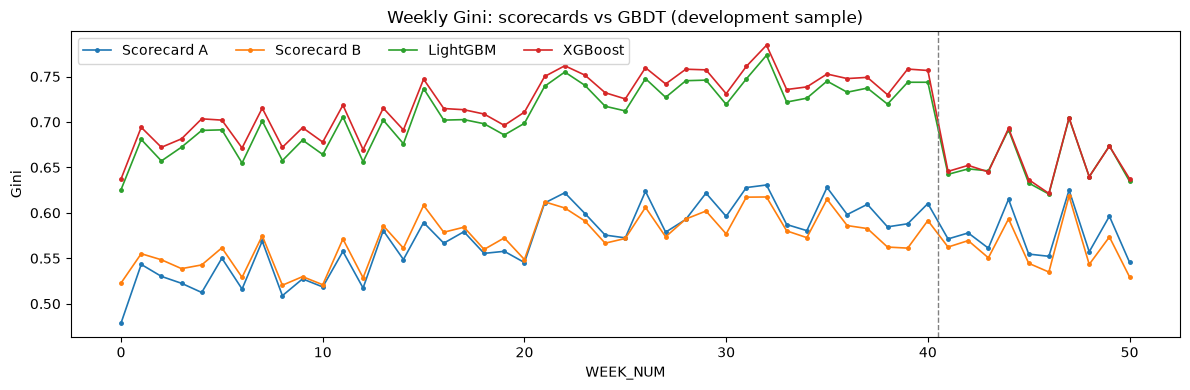

In [6]:
bp_a, sc_a = load_scorecard("A")
_, sc_b = load_scorecard("B")
need = sorted(set(sc_a["features"]) | set(sc_b["features"]))
sc_df = (pl.scan_parquet(RES_DIR / "model_data.parquet").filter(pl.col("WEEK_NUM") <= VALID_END).select(need).collect()
           .with_columns(pl.col(pl.Boolean).cast(pl.Float32)).to_pandas())
p_lgb, p_xgb = np.empty(len(y)), np.empty(len(y))
p_lgb[is_tr], p_lgb[~is_tr] = p_tr_lgb, p_va_lgb
p_xgb[is_tr], p_xgb[~is_tr] = p_tr_xgb, p_va_xgb
preds = {"Scorecard A": -scorecard_score(bp_a, sc_a, sc_df), "Scorecard B": -scorecard_score(bp_a, sc_b, sc_df),
         "LightGBM": p_lgb, "XGBoost": p_xgb}
del sc_df; _ = gc.collect()

rows, weekly = [], {}
for name, p in preds.items():
    mt, mv = metrics(y[is_tr], p[is_tr]), metrics(y[~is_tr], p[~is_tr])
    weekly[name] = weekly_gini(wk, y, p)
    rows.append({"model": name, "AUC_train": mt["AUC"], "AUC_valid": mv["AUC"], "KS_valid": mv["KS"],
                 "gap": round(mt["AUC"] - mv["AUC"], 4),
                 "weekly_gini_mean_valid": round(float(weekly[name][weekly[name].index > TRAIN_END].mean()), 4)})
cmp = pl.DataFrame(rows).with_columns(pl.Series("train_seconds", [None, None, t_lgb, round(t_xgb)]))
display(cmp)

fig, ax = plt.subplots(figsize=(12, 4))
for name, s in weekly.items():
    ax.plot(s.index, s.values, marker="o", ms=2.5, lw=1.2, label=name)
ax.axvline(TRAIN_END + 0.5, color="grey", ls="--", lw=1)
ax.set_xlabel("WEEK_NUM"); ax.set_ylabel("Gini"); ax.set_title("Weekly Gini: scorecards vs GBDT (development sample)")
ax.legend(ncol=4); plt.tight_layout(); savefig(fig, "07_dev_weekly_gini"); plt.show()

## 6. Feature importance

In [7]:
imp_l = pd.Series(lgb_model.feature_importance(importance_type="gain"), index=FEATS_FINAL)
imp_x = pd.Series(xgb_model.get_score(importance_type="total_gain")).reindex(FEATS_FINAL).fillna(0)
imp = (pl.DataFrame({"feature": FEATS_FINAL, "lgb_gain_share": (imp_l / imp_l.sum()).values,
                     "xgb_gain_share": (imp_x / imp_x.sum()).values})
         .join(sel.select("feature", "table", "iv_train", "psi_train_valid", "monitor"), on="feature", how="left")
         .with_columns(pl.col("feature").is_in(sc_a["features"]).alias("in_scorecard_A"))
         .sort("lgb_gain_share", descending=True))
display(imp.head(25).with_columns(pl.col("lgb_gain_share", "xgb_gain_share").round(4)))
display(imp.group_by("table").agg(pl.col("lgb_gain_share").sum().round(3), pl.col("xgb_gain_share").sum().round(3),
                                  pl.len().alias("n_features")).sort("lgb_gain_share", descending=True))

feature,lgb_gain_share,xgb_gain_share,table,iv_train,psi_train_valid,monitor,in_scorecard_A
str,f64,f64,str,f64,f64,bool,bool
"""pmts_dpd_1073P__mean""",0.0495,0.0577,"""credit_bureau_a_2""",0.282238,0.019008,false,true
"""avgdpdtolclosure24_3658938P""",0.0468,0.05,"""depth0""",0.301756,0.000168,false,true
"""numberofoverdueinstlmax_1039L_…",0.036,0.0228,"""credit_bureau_a_1""",0.237114,0.019205,false,false
"""incometype_1044T__first""",0.0319,0.0254,"""person_1""",0.083198,0.0059,false,true
"""dpdmaxdateyear_596T_yrsago__me…",0.0279,0.0242,"""credit_bureau_a_1""",0.22707,1.071862,true,true
…,…,…,…,…,…,…,…
"""overdueamountmax2_14A__mean""",0.013,0.0173,"""credit_bureau_a_1""",0.200434,0.018081,false,false
"""pctinstlsallpaidlate1d_3546856…",0.0127,0.0092,"""depth0""",0.26707,0.000257,false,false
"""pmts_overdue_1152A__mean""",0.0125,0.0136,"""credit_bureau_a_2""",0.214984,0.617618,true,true


table,lgb_gain_share,xgb_gain_share,n_features
str,f64,f64,u32
"""depth0""",0.377,0.36,62
"""credit_bureau_a_1""",0.308,0.304,44
"""applprev_1""",0.113,0.136,41
"""credit_bureau_a_2""",0.089,0.094,6
"""person_1""",0.069,0.062,5
"""tax_unified""",0.043,0.043,5
"""applprev_2""",0.001,0.001,3


In [8]:
lgb_model.save_model(str(RES_DIR / "07_lgb.txt"), num_iteration=lgb_model.best_iteration)
xgb_model.save_model(str(RES_DIR / "07_xgb.json"))
meta = {"config": f"{CAT_CHOSEN} + {REG_CHOSEN}", "features": FEATS_FINAL, "categorical": CAT_FINAL,
        "categories": {c: SPEC[c] for c in CAT_FINAL}, "merged_other": MERGED, "other_label": OTHER,
        "extra_drop": EXTRA_DROP, "lgb_best_iteration": int(lgb_model.best_iteration), "xgb_best_iteration": int(best_x),
        "lgb_params": LGB_PARAMS, "xgb_params": XGB_PARAMS}
(RES_DIR / "07_gbdt_meta.json").write_text(json.dumps(meta, indent=1))
imp.write_csv(RES_DIR / "07_feature_importance.csv", include_bom=True)
cmp.write_csv(RES_DIR / "07_dev_comparison.csv", include_bom=True)
exp1.write_csv(RES_DIR / "07_exp1_categorical.csv", include_bom=True)
exp2.write_csv(RES_DIR / "07_exp2_regularisation.csv", include_bom=True)
print("saved: 07_lgb.txt, 07_xgb.json, 07_gbdt_meta.json, 07_feature_importance.csv, 07_dev_comparison.csv, 07_exp*.csv")

saved: 07_lgb.txt, 07_xgb.json, 07_gbdt_meta.json, 07_feature_importance.csv, 07_dev_comparison.csv, 07_exp*.csv
